Meeting with Max
- 4x stages of diff
- cells needed for crispra study
- 50 tfs per module 4x
	- pluri -> definitive endoderm -> anterior foregut endoderm -> pharengial endoderm -> para thyroid (or thymos)
- ~3 guides per tfactor
- "how many cells do you need to resolve the difference"
- crispra piggybac vs lenti
- what MOI do you want & how many cells do you need?
- probably ending up with 4-6 TFs that specify the result
- "what are the necessary factors? do we need to pulse them over time, or can we just"
- PTH reporter line
- introduce each module of 50 separately into the , then stain for marker of development for each stage
- average subset size of 4-5
- FACS to get the actual guides
- Say we assume 1-2 % be visible
- "how many cells do we actually need"

Scratch
- We model the total number of transfection events per cell with a poisson rate distribution (we assume transfection happens over some interval of time, the chance of a given construct -> classic constant rate process. if we count num transfected = total number of transfection events, then we can consider the total number of tfection events poisson distributed with some mean $\mu$, which is also our *actual MOI*.)
- How many targets are we hitting? Let's first assume that guide efficiency is 100% and we have the same number of guides for each factor. we hit $M$ targets, where $M\approx 50$ (module size)
- We want each cell to get, on average, 4-5 *different* TFs. We will say this is $u\approx5$ (u for unique)
- If we pick $p$ distinct transcription factors from $M$ total with replacement, what's the chance we get at least $m$ distinct TFs?
- Introduction to Probability Models, 13th ed, pg 128 has a nice result: if a poisson process after being sampled then has some number of independent classes n1, n2, n3, ... each with prob p1, p2, p3.., the pmf of each outcome is just poisson again but you multiply the rate parameter by prob. So (last equation example 3.24, marganilize everything out except the one you want)
- e.g. 
$$p(N_1=n_1)=\frac{e^{-\lambda p_n}(\lambda p_n) ^{n_1}}{n_1!}$$

"prob that class N_1 (class=tf) is observed n_1 times is..."

- We can say "number distinct tfs" is just "number tfected >= 1 times"
$$P(N_1>0)=1-P(N_1=0)$$
$$P(N_1=0)=1-\frac{e^{-\lambda p_n}(\lambda p_n) ^{0}}{0!}$$
$$P(N_1=0)=1-e^{-\lambda p_n}$$

- we already asumed efficiency is the same for all of them, so $p_n=1/M$
- can totally relax this constraint if we think 

$$P(N_1=0)=1-e^{-\lambda /M}$$

- then we want $P(U=u)$. (pmf of unique)
- $u=I(N_1)+I(N_2)...I(N_M)$ (number of unique is sum of indicator variables, each with same prob... This is binomial distributed!)
$$P(U=u)= Binomial(1-e^{-\lambda p_n},M) \tag{uniq}$$



In [3]:
from scipy.stats import binom
import numpy as np
import matplotlib.pyplot as plt

def plot_prob(module_size, effective_moi):
    M = module_size
    q = 1 - np.exp(-effective_moi / M)
    ks = np.arange(0, M + 1)
    pmf = binom.pmf(ks, M, q)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(ks, pmf)
    ax.set_xlabel("number of unique TFs in a cell")
    ax.set_ylabel("Probability")
    ax.set_title(f"M={M}, MOI={effective_moi}  →  E[K]={M*q:.2f}")

    nonzero = ks[pmf > 1e-4]
    if len(nonzero):
        ax.set_xlim(nonzero.min() - 0.5, nonzero.max() + 0.5)
    return fig, ax

(<Figure size 800x400 with 1 Axes>,
 <Axes: title={'center': 'M=50, MOI=5  →  E[K]=4.76'}, xlabel='number of unique TFs hit (K)', ylabel='P(K = k)'>)

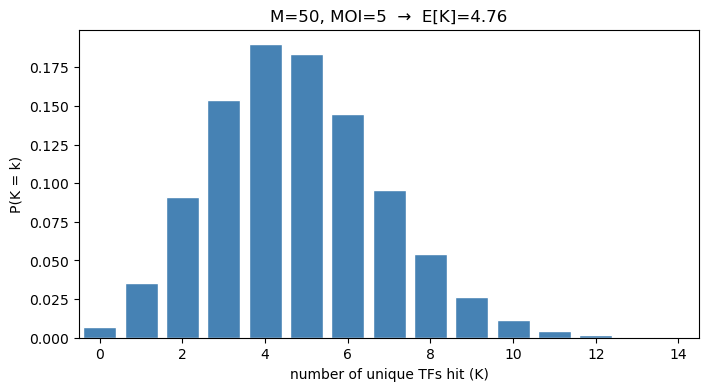

In [2]:
plot_prob(50,5)

(<Figure size 800x400 with 1 Axes>,
 <Axes: title={'center': 'M=50, MOI=2  →  E[K]=1.96'}, xlabel='number of unique TFs in a cell', ylabel='Probability'>)

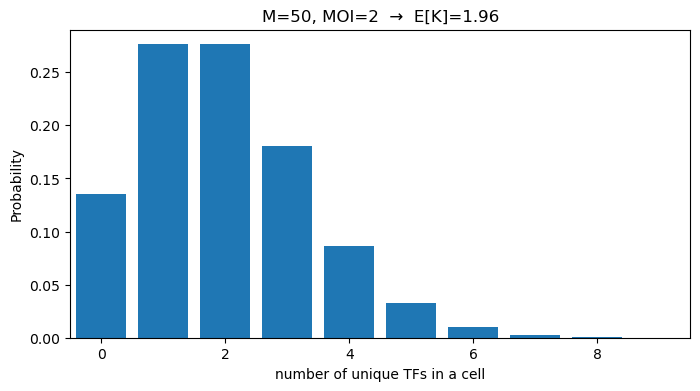

In [4]:
plot_prob(50,2)

(<Figure size 800x400 with 1 Axes>,
 <Axes: title={'center': 'M=50, MOI=7  →  E[K]=6.53'}, xlabel='number of unique TFs in a cell', ylabel='Probability'>)

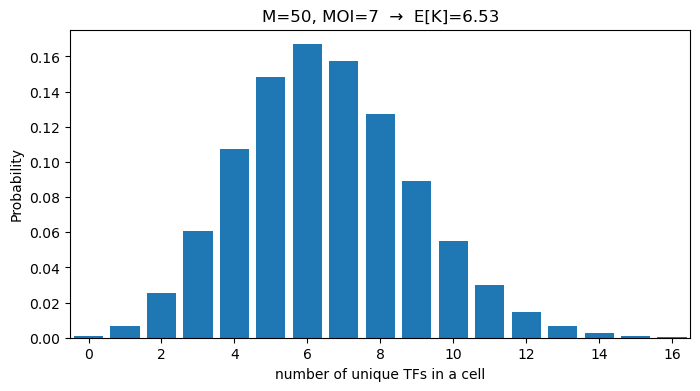

In [5]:
plot_prob(50,7)

Ok, now i want to know "what % of cells end up with the right combo". This, combined with "i want 100,000 differentiated cells" or whatever can calculate how many cells you need. We make the simplifying assumption that if a cell gets the "golden path" TFs and then some extras, it still differentiates.
- we can say that P(differentiation) is just the probability of getting each 


possible implication: instead of taregting 4-5 unique tfected per cell, if we think "spoiler" TFs dont exist, it might be easier to target the upper MOI range and deduce the important TFs from what does NOT exist. 

Future work: 
- [ ] deal with guide-guide variability
- [ ] make estimate more pessimistic by deciding that tfection efficiency is <100% ad that P(differentiation) is less than just prob of (can get all the right TFs and still fail to diff)
- [ ] decide on some number of "spoiler" TFs which mess up differentiation iff tfected along with the "golden path" TFs. 